In [1]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/Dataset/Car_Bike_dataset.zip"

Archive:  /content/drive/MyDrive/Dataset/Car_Bike_dataset.zip
   creating: Car_Bike_dataset/
   creating: Car_Bike_dataset/test/
   creating: Car_Bike_dataset/test/Bike/
  inflating: Car_Bike_dataset/test/Bike/Bike (1004).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1005).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1006).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1007).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1008).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1009).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1010).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1011).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1012).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1013).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1014).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1015).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1016).jpeg  
  inflating: Car_Bike_dataset/test/Bike/Bike (1017).jpeg  
  in

### Importing

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input , Dense , Conv2D , Dropout , Flatten , MaxPooling2D , Rescaling , BatchNormalization
from keras.utils import image_dataset_from_directory , load_img , img_to_array
from keras.optimizers import Adam , RMSprop , SGD
from keras.losses import CategoricalCrossentropy

### Loading Images

In [47]:
train = image_dataset_from_directory(directory = "/content/Car_Bike_dataset/train" ,
                                     image_size = (224 , 224) ,
                                     color_mode = "rgb" ,
                                     batch_size = 32)

test = image_dataset_from_directory(directory = "/content/Car_Bike_dataset/test" ,
                                     image_size = (224 , 224) ,
                                     color_mode="rgb" ,
                                     batch_size = 32)

class_names = train.class_names
print(class_names)

Found 1400 files belonging to 2 classes.
Found 600 files belonging to 2 classes.
['Bike', 'Car']


### Min Max Scaling

In [48]:
normalization_layer = Rescaling(1.0 / 255.0)

train = train.map(lambda x , y : (normalization_layer(x) , y))
test = test.map(lambda x , y : (normalization_layer(x) , y))

### One Hot Encoding

In [49]:
def one_hot_encoder(x , y):
  y = tf.one_hot(y , depth = 2)
  return x , y

train = train.map(one_hot_encoder)
test = test.map(one_hot_encoder)

### Adding Layers

In [50]:
model = Sequential()

model.add(Input((224 , 224 , 3)))
model.add(Conv2D(32 , (3 , 3) , kernel_initializer = "he_uniform" , padding = "same" , activation = "relu"))
model.add(BatchNormalization())

model.add(Conv2D(32 , (3 , 3) , kernel_initializer = "he_uniform" , padding = "same" , activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2 , 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64 , (3 , 3) , kernel_initializer = "he_uniform" , padding = "same" , activation = "relu"))
model.add(BatchNormalization())

model.add(Conv2D(64 , (3 , 3) , kernel_initializer = "he_uniform" , padding = "same" , activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2 , 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128 , (3 , 3) , kernel_initializer = "he_uniform" , padding = "same" , activation = "relu"))
model.add(BatchNormalization())

model.add(Conv2D(128 , (3 , 3) , kernel_initializer = "he_uniform" , padding = "same" , activation = "relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2 , 2)))
model.add(Dropout(0.2))
model.add(Flatten())

model.add(Dense(512 , activation = "relu"))
model.add(Dropout(0.3))
model.add(Dense(256 , activation = "relu"))
model.add(Dropout(0.3))
model.add(Dense(128 , activation = "relu"))
model.add(Dropout(0.3))
model.add(Dense(64 , activation = "relu"))
model.add(Dropout(0.3))
model.add(Dense(2 , activation = "softmax"))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,32

 Total params: 51,842,146 (197.76 MB)

 Trainable params: 51,841,250 (197.76 MB)

 Non-trainable params: 896 (3.50 KB)

### Compiling Model

In [51]:
model.compile(loss = CategoricalCrossentropy() , optimizer = RMSprop(learning_rate = 0.001) , metrics = ["accuracy"])

### Training Model

In [52]:
history = model.fit(train , validation_data = test , epochs = 20)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 419ms/step - accuracy: 0.5521 - loss: 14.3151 - val_accuracy: 0.4983 - val_loss: 2.4623
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - accuracy: 0.6407 - loss: 4.9959 - val_accuracy: 0.5000 - val_loss: 4.4861
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.6486 - loss: 2.8932 - val_accuracy: 0.4467 - val_loss: 1.1129
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.6836 - loss: 1.6036 - val_accuracy: 0.5000 - val_loss: 1.5816
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.7793 - loss: 0.7777 - val_accuracy: 0.5000 - val_loss: 2.1361
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.8264 - loss: 0.5235 - val_accuracy: 0.6267 - val_loss: 0.7199
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.8464 - loss: 0.4264 - val_accuracy: 0.7433 - val_loss: 0.4859
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step - accuracy: 0.9050 - loss: 0.3402 - val_accuracy

### History Visualization

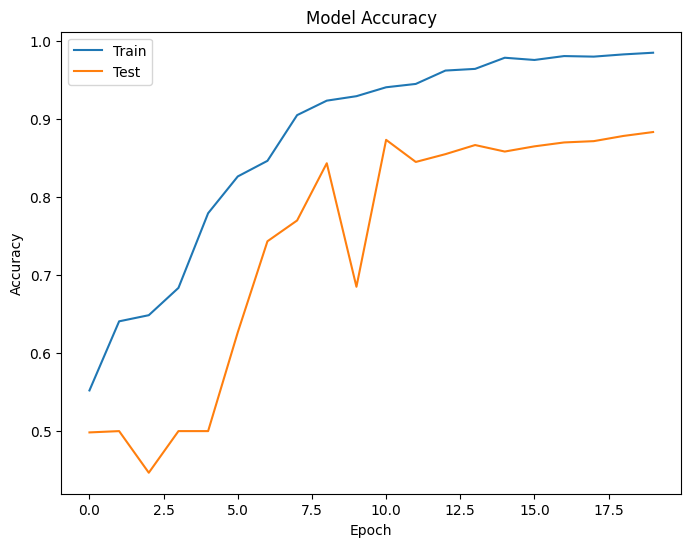

In [53]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train" , "Test"])
plt.show()

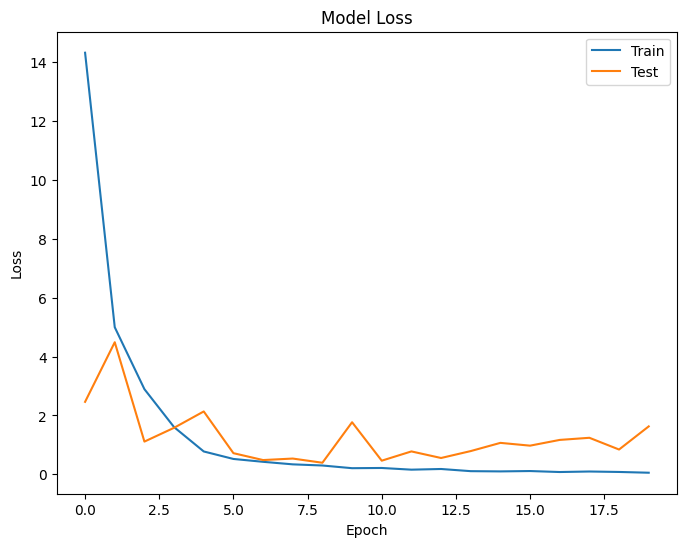

In [54]:
plt.figure(figsize = (8 , 6))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train" , "Test"])
plt.show()

### Evaluation

In [55]:
result = model.evaluate(test , verbose = 0)
print(f"Accuracy : {result[1]} , Loss : {result[0]}")

Accuracy : 0.8833333253860474 , Loss : 1.6290075778961182


### Prediction

In [57]:
img_path = "/content/Car_Bike_dataset/test/Bike/Bike (1004).jpeg"

img = load_img(img_path , target_size = (224 , 224) , color_mode = "rgb")

img = img_to_array(img)

img = img / 255.0

img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: Bike
